### Example 1a: Taylor series for a polynomial

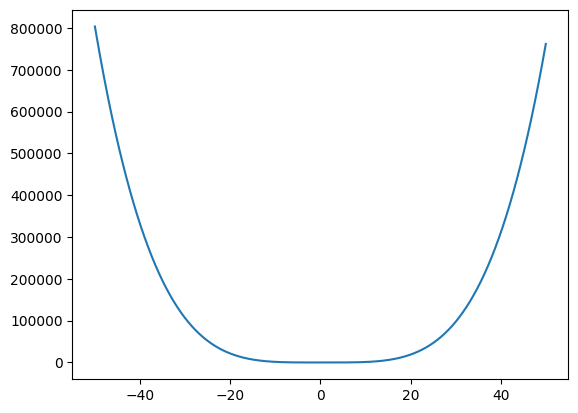

In [2]:
from math import factorial, sin, cos, e
import numpy as np
import matplotlib.pyplot as plt

#Play around with Taylor series for a fourth order polynomial f(x)

def f(x):
    return 1/8*x**4 -1/6*x**3+1/2*x**2-1/2*x+2

#use the matplotlib library to plot this function. what is its general behavior?

xs = np.linspace(-50, 50, 500)
ys = f(xs)
plt.plot(xs,ys)
plt.show()

In [3]:
#define functions for all of the derivatives of our polynomial

def f_1(x):
    return .5*x**3-.5*x**2+x-.5
def f_2(x):
    return 1.5*x**2-x+1
def f_3(x):
    return 3*x-1
def f_4(x):
    return 3

#put all of these derivatives together to form the Taylor series
def T(x,a):
    return f(a)+f_1(a)*(x-a)+f_2(a)/factorial(2) * (x-a)**2 + f_3(a)/factorial(3) * (x-a)**3 + f_4(a)/factorial(4) * (x-a)**4


#calculate the Taylor series estimate for x=1.5, using a Taylor series constructed around a=0.5
print('estimate for x=1.5 and a=.5: ',T(1.5,0.5))

#calculate the Taylor series estimate for x=1.5, using a Taylor series constructed around a=1
print('estimate for x=1.5 and a=1: ',T(1.5,1))

#calculate the analytical solution for f(1.5). how does this compare with our two estimates? which type(s) of error are we seeing?
print('true result for x=1.5: ', f(1.5))


#similar exercise for x=4
print('estimate for x=4 and a=1: ',T(4,1))
print('true result for x=4: ',f(4))

estimate for x=1.5 and a=.5:  2.4453125000000004
estimate for x=1.5 and a=1:  2.4453125
true result for x=1.5:  2.4453125
estimate for x=4 and a=1:  29.333333333333336
true result for x=4:  29.333333333333336


In [4]:
#try the linear approximation -- just 2 terms of the Taylor series:
def T_1(x,a):
    return f(a)+f_1(a)*(x-a)

#now reconsider the estimate for x=4, using truncated Taylor series constructed around a=.5,a=1 and a=3.5 
#How do results compare with the analytical solution? which type(s) of error do we have in this case?
print('true result for x=4: ',f(4))
print('estimate for x=4 and a=.5: ',T_1(4,.5))
print('estimate for x=4 and a=1: ',T_1(4,1))
print('estimate for x=4 and a=3.5: ',T_1(4,3.5))

#plot the truncated Taylor series, non-truncated Taylor series and original function using Matplotlib. 
#Compare the three functions. Where do they diverge?
#(analytical question) what is the quantitative error of the truncated Taylor series?

true result for x=4:  29.333333333333336
estimate for x=4 and a=.5:  1.6432291666666667
estimate for x=4 and a=1:  3.4583333333333335
estimate for x=4 and a=3.5:  27.143229166666668


Example 1b: Taylor series for a triginometric function

In [5]:
def g(x):
    return sin(x) + cos(x)


In [104]:
#construct a Taylor series for g(x) around a=0. Truncate this Taylor series after the first 5 terms.
#note that you may wish to use the known Maclauren series for sin(x) and cos(x) to do this.



In [105]:
#calculate the estimated values for x=0.5,1,2,and 4 using your Taylor series. compare with the analytical values.
#plot the original function and your Taylor series. how quickly does the truncated series diverge from the true function?


### Example 2: finding roots with Newton-Raphson

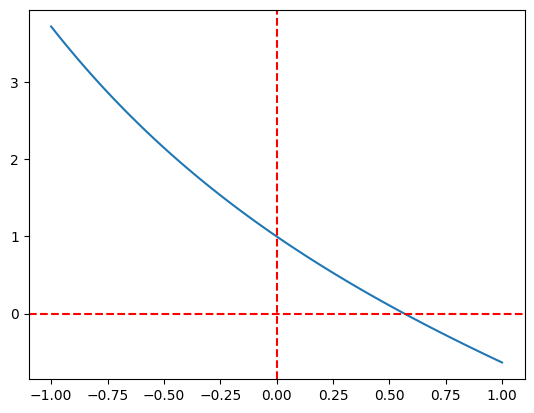

In [6]:
#function we will find roots for

epsilon=.0001 #required accuracy

def h(x):
    return e**(-x) -x

#plot this function
xs = np.linspace(-1, 1, 100)
ys = [h(x0) for x0 in xs]
plt.plot(xs,ys)
plt.axvline(x=0,color='r', linestyle='--')
plt.axhline(y=0,color='r', linestyle='--')
plt.show()

In [8]:
#based on your plot, pick an initial x_guess for the root location

x_guess = 1.0

#evaluate the function at the location of our guess
y0 = h(x_guess)
print('value of y at initial guess= ',y0)

value of y at initial guess=  -0.6321205588285577


In [9]:
#define a function to evaluate derivatives of h(x)

def deriv_h(x):
    return -1*e**(-x) -1

#first make sure the derivative of h(x) is not zero at our current guess
print('current derivative= ',deriv_h(x_guess))

current derivative=  -1.3678794411714423


In [10]:
#define a function to evaluate the Newton-Raphson formula to update your root guess

def nr_update(x1):
    x2 = x1 - (h(x1)/deriv_h(x1))
    return x2

In [11]:
#evaluate the new x_guess
x_guess_new = nr_update(x_guess)
print('xi+1= ', x_guess_new, 'h(xi+1) = ',h(x_guess_new))

#did our estimate of the root improve in a single iteration? 

xi+1=  0.5378828427399902 h(xi+1) =  0.046100486291689724


In [12]:
#define function to evaluate relative error
def error_size(x1,x2):
    return (x2-x1)/x1

err = error_size(x_guess, x_guess_new)

print('relative error: ', err)


# is our error within the required accuracy?

if(abs(err) < epsilon):
    print('done! achieved required accuracy')
else:
    print('accuracy not achieved yet')

relative error:  -0.4621171572600098
accuracy not achieved yet


In your homework assignment, you will be tasked to write an algorithm that performs all of these steps without requiring user input along the way.